# Patient figures
Cleaned: live cells only (dead iterations removed). Cohort 10 LH / 12 RH (sub-076 corrected).


## Patient table

In [1]:
import pandas as pd
# Public patient table — CORRECTED COHORT (sub-076 -> RH-intact). Figure order.
# Two surgery categories: "Hemispherectomy" | "OTC resection". No sub_bids (kept in gitignored key).
_rows = [
    ("P01","F","Hemispherectomy","R hemisphere","Left"),
    ("P02","M","OTC resection","R occipito-temporal","Left"),
    ("P03","F","OTC resection","R temporal","Left"),
    ("P04","F","Hemispherectomy","R hemisphere","Left"),
    ("P05","F","Hemispherectomy","R hemisphere","Left"),
    ("P06","M","OTC resection","R occipito-temporal","Left"),
    ("P07","F","OTC resection","R temporal","Left"),
    ("P08","M","OTC resection","R temporo-parietal","Left"),
    ("P09","M","OTC resection","R parieto-occipital","Left"),
    ("P10","M","Hemispherectomy","R hemisphere","Left"),
    ("P11","M","Hemispherectomy","L hemisphere","Right"),
    ("P12","F","Hemispherectomy","L hemisphere","Right"),
    ("P13","M","OTC resection","L temporal","Right"),
    ("P14","M","Hemispherectomy","L hemisphere","Right"),
    ("P15","F","OTC resection","L parieto-occipital","Right"),
    ("P16","F","Hemispherectomy","L hemisphere","Right"),
    ("P17","M","OTC resection","L occipito-temporal","Right"),
    ("P18","F","Hemispherectomy","L hemisphere","Right"),
    ("P19","M","Hemispherectomy","L hemisphere","Right"),
    ("P20","F","Hemispherectomy","L hemisphere","Right"),
    ("P21","M","OTC resection","L temporal (superior)","Right"),
    ("P22","F","OTC resection","L temporal","Right"),
]
patient_table = pd.DataFrame(_rows, columns=["Patient","Sex","Surgery type","Site","Intact"])
with pd.option_context("display.max_colwidth", None):
    display(patient_table)
# print(patient_table.to_latex(index=False))  # manuscript version


/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,Patient,Sex,Surgery type,Site,Intact
0,P01,F,Hemispherectomy,R hemisphere,Left
1,P02,M,OTC resection,R occipito-temporal,Left
2,P03,F,OTC resection,R temporal,Left
3,P04,F,Hemispherectomy,R hemisphere,Left
4,P05,F,Hemispherectomy,R hemisphere,Left
5,P06,M,OTC resection,R occipito-temporal,Left
6,P07,F,OTC resection,R temporal,Left
7,P08,M,OTC resection,R temporo-parietal,Left
8,P09,M,OTC resection,R parieto-occipital,Left
9,P10,M,Hemispherectomy,R hemisphere,Left


## Figure 1 — Cross-sectional (timeline + table + age strip + surgery type)

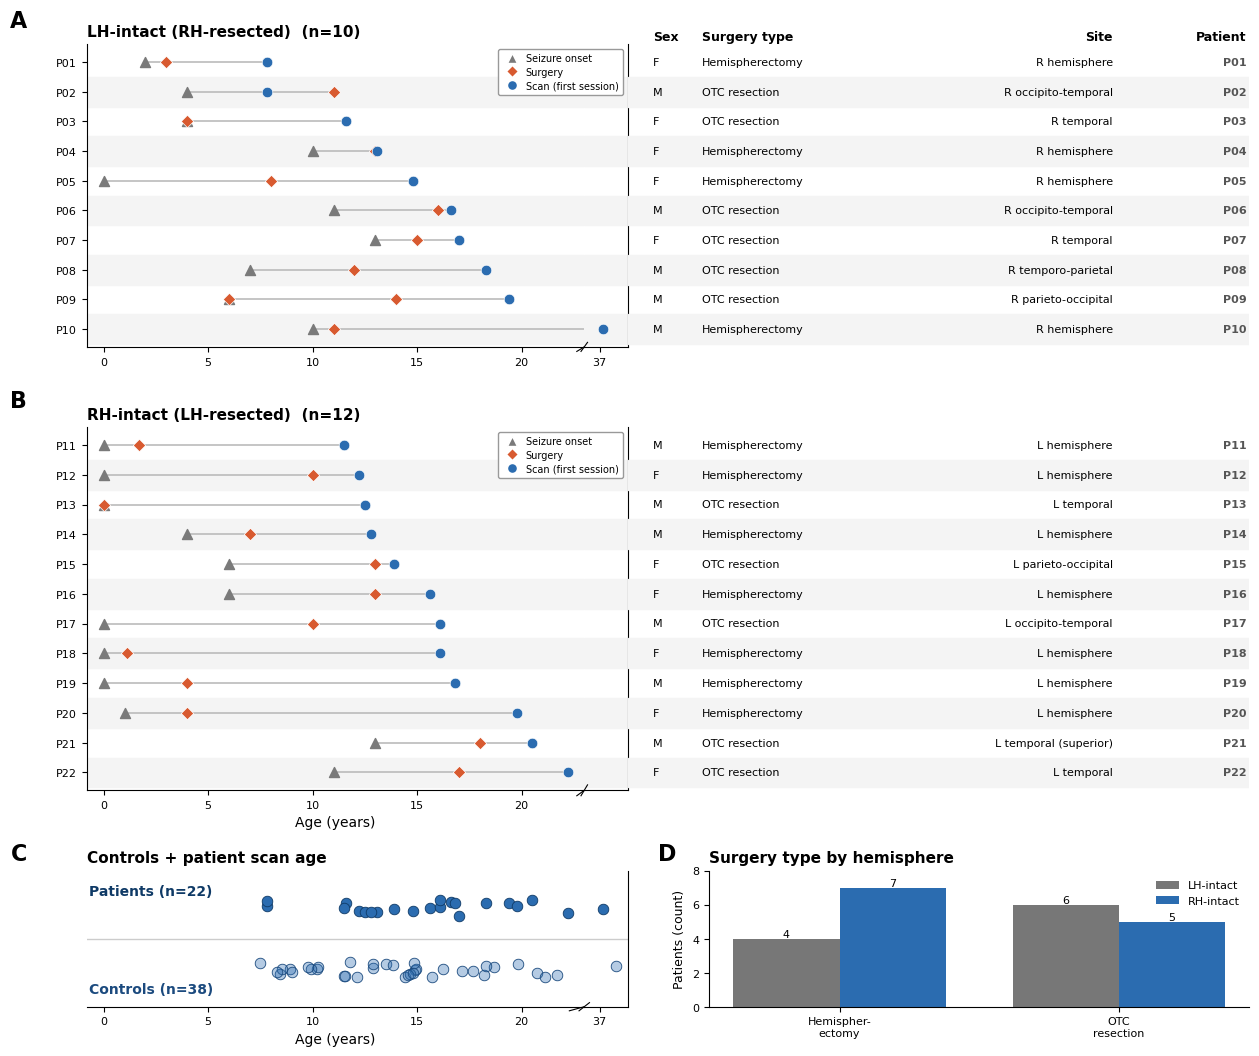

In [2]:
#!/usr/bin/env python
"""
Full cross-sectional figure, one canvas:
  A  LH-intact (RH-resected): timeline + metadata table
  B  RH-intact (LH-resected): timeline + metadata table
  C  Controls + patient scan age (jittered strip, enlarged text)
Shared age axis with a 37y break. White table background, alternating row bands.
"""
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ---- control ages: point at the live CSV on the cluster ----
CSV = "/user_data/csimmon2/git_repos/sym_pt/sub_info.csv"
CTRL_EXCLUDE = {"sub-027", "sub-084"}

C_SCAN  = "#2B6CB0"
C_EDGE_C= "#1B4A7E"   # control outline (slightly darker)
C_EDGE_P= "#0F3A66"   # patient outline (darker still)
C_SEIZ, C_SURG = "#7A7A7A", "#D85A30"
LINE, BAND = "#BBBBBB", "#F4F4F4"
MAIN_MAX, BRK_LO, BRK_HI = 23, 35.5, 39.7
rng = np.random.default_rng(7)

# (pid, sex, surgery, site, seizure, surgery_age, scan)
LH = [
    ("P01","F","Hemispherectomy",                "R hemisphere",                2.0,  3.0,  7.8),
    ("P02","M","OTC resection",                "R occipito-temporal",         4.0, 11.0,  7.8),
    ("P03","F","OTC resection",                "R temporal",                  4.0,  4.0, 11.6),
    ("P04","F","Hemispherectomy",                "R hemisphere",               10.0, 13.0, 13.1),
    ("P05","F","Hemispherectomy",                "R hemisphere",                0.0,  8.0, 14.8),
    ("P06","M","OTC resection", "R occipito-temporal",        11.0, 16.0, 16.6),
    ("P07","F","OTC resection",                "R temporal",      13.0, 15.0, 17.0),
    ("P08","M","OTC resection",                "R temporo-parietal",  7.0, 12.0, 18.3),
    ("P09","M","OTC resection", "R parieto-occipital",         6.0,(6.0,14.0),19.4),
    ("P10","M","Hemispherectomy",                "R hemisphere",               10.0, 11.0, 37.3),
]
RH = [
    ("P11","M","Hemispherectomy",                "L hemisphere",                0.0,  1.7, 11.5),
    ("P12","F","Hemispherectomy",                "L hemisphere",                0.0, 10.0, 12.2),
    ("P13","M","OTC resection", "L temporal",                  0.0,  0.0, 12.5),
    ("P14","M","Hemispherectomy",                "L hemisphere",                4.0,  7.0, 12.8),
    ("P15","F","OTC resection",                "L parieto-occipital",         6.0, 13.0, 13.9),
    ("P16","F","Hemispherectomy",                "L hemisphere",                6.0, 13.0, 15.6),
    ("P17","M","OTC resection",                "L occipito-temporal",         0.0, 10.0, 16.1),
    ("P18","F","Hemispherectomy",                "L hemisphere",                0.0,  1.1, 16.1),
    ("P19","M","Hemispherectomy",                "L hemisphere",                0.0,  4.0, 16.8),
    ("P20","F","Hemispherectomy",                "L hemisphere",                1.0,  4.0, 19.8),
    ("P21","M","OTC resection", "L temporal (superior)",      13.0, 18.0, 20.5),
    ("P22","F","OTC resection",                "L temporal",      11.0, 17.0, 22.2),
]
PT_SCAN = np.array([r[6] for r in LH+RH])
COLX = {"Sex":0.04, "Surgery type":0.12, "Site":0.78, "Patient":0.995}

def split(a): return a[a<=MAIN_MAX], a[a>=BRK_LO]
def bands(ax, n):
    for r in range(n):
        if r % 2 == 0: ax.axhspan(r-0.5, r+0.5, color=BAND, zorder=0)
def panel_letter(ax, L, dx=-0.12):
    ax.text(dx, 1.04, L, transform=ax.transAxes, fontsize=16, fontweight="bold",
            va="bottom", ha="right")

def draw_timeline(axm, axb, rows, blank_break=False):
    n=len(rows); bands(axm,n); bands(axb,n)
    for i,row in enumerate(rows):
        pid,_,_,_,sz,su,sc=row; y=n-1-i
        su_list=list(su) if isinstance(su,(tuple,list)) else [su]
        axm.plot([min([sz]+su_list+[sc]), min(max([sz]+su_list+[sc]),MAIN_MAX)],[y,y],color=LINE,lw=1.2,zorder=1)
        for ax in (axm,axb):
            ax.scatter(sz,y,marker="^",s=52,color=C_SEIZ,zorder=3)
            for sv in su_list: ax.scatter(sv,y,marker="D",s=40,color=C_SURG,zorder=3,edgecolors="white",linewidths=.5)
            ax.scatter(sc,y,marker="o",s=58,color=C_SCAN,zorder=3,edgecolors="white",linewidths=.5)
    axm.set_yticks(range(n)); axm.set_yticklabels([r[0] for r in reversed(rows)],fontsize=8)
    axm.set_ylim(-0.6,n-0.4); axm.set_xlim(-0.8,MAIN_MAX)
    axb.set_xlim(BRK_LO,BRK_HI); axb.set_yticks([]); axb.set_ylim(-0.6,n-0.4)
    axb.set_xticks([] if blank_break else [37])
    axm.spines["right"].set_visible(False); axb.spines["left"].set_visible(False)
    for ax in (axm,axb): ax.spines["top"].set_visible(False); ax.tick_params(labelsize=8)
    d=.015; kw=dict(transform=axm.transAxes,color="k",clip_on=False,lw=.8)
    axm.plot((1-d,1+d),(-d,d),**kw); kw.update(transform=axb.transAxes); axb.plot((-d*5,d*5),(-d,d),**kw)

def draw_table(ax, rows, header=False):
    n=len(rows); bands(ax,n); ax.set_xlim(0,1); ax.set_ylim(-0.6,n-0.4); ax.axis("off")
    for i,row in enumerate(rows):
        pid,sex,surg,site=row[0],row[1],row[2],row[3]; y=n-1-i
        ax.text(COLX["Sex"],y,sex,ha="left",va="center",fontsize=8)
        ax.text(COLX["Surgery type"],y,surg,ha="left",va="center",fontsize=8)
        ax.text(COLX["Site"],y,site,ha="right",va="center",fontsize=8)
        ax.text(COLX["Patient"],y,pid,ha="right",va="center",fontsize=8,fontweight="bold",color="#555555")
    if header:
        for label,x in COLX.items():
            ha="right" if label in ("Site","Patient") else "left"
            ax.text(x,n-0.35,label,ha=ha,va="bottom",fontsize=9,fontweight="bold",clip_on=False)

def draw_strip(axm, axb):
    # enlarged text strip: patients (solid) up, controls (translucent) down
    df=pd.read_csv(CSV); ctrl=df[df["group"].str.lower()=="control"].copy()
    ctrl=ctrl[~ctrl["sub"].isin(CTRL_EXCLUDE)]
    ctrl["sesnum"]=ctrl["ses"].str.extract(r"(\d+)").astype(int)
    ctrl=ctrl.sort_values("sesnum").drop_duplicates("sub",keep="first")
    cage=ctrl["age"].values
    axm.axhline(0,color="#CCCCCC",lw=1,zorder=0); axb.axhline(0,color="#CCCCCC",lw=1,zorder=0)
    pm,pbk=split(PT_SCAN); cm,cbk=split(cage)
    axm.scatter(pm,0.45+rng.uniform(-.12,.12,len(pm)),s=58,color=C_SCAN,edgecolors=C_EDGE_P,linewidths=.6,zorder=3)
    axm.scatter(cm,-0.45+rng.uniform(-.12,.12,len(cm)),s=58,facecolors=(0.169,0.424,0.690,0.35),edgecolors=C_EDGE_C,linewidths=.6,zorder=3)
    axb.scatter(pbk,0.45+rng.uniform(-.05,.05,len(pbk)),s=58,color=C_SCAN,edgecolors=C_EDGE_P,linewidths=.6,zorder=3)
    axb.scatter(cbk,-0.45+rng.uniform(-.05,.05,len(cbk)),s=58,facecolors=(0.169,0.424,0.690,0.35),edgecolors=C_EDGE_C,linewidths=.6,zorder=3)
    axm.set_xlim(-0.8,MAIN_MAX); axb.set_xlim(BRK_LO,BRK_HI)
    for ax in (axm,axb):
        ax.set_ylim(-1,1); ax.set_yticks([]); ax.spines["top"].set_visible(False); ax.spines["left"].set_visible(False)
        ax.tick_params(labelsize=8)
    axm.spines["right"].set_visible(False); axb.spines["left"].set_visible(False); axb.set_xticks([37])
    d=.03; kw=dict(transform=axm.transAxes,color="k",clip_on=False,lw=.8)
    axm.plot((1-d,1+d),(-d,d),**kw); kw.update(transform=axb.transAxes); axb.plot((-d*4,d*4),(-d,d),**kw)
    axm.set_xlabel("Age (years)",fontsize=10)
    axm.text(0.005,.82,f"Patients (n={len(PT_SCAN)})",transform=axm.transAxes,fontsize=10,color=C_EDGE_P,fontweight="bold")
    axm.text(0.005,.10,f"Controls (n={len(cage)})",transform=axm.transAxes,fontsize=10,color=C_EDGE_C,fontweight="bold")


def draw_surgtype(ax):
    cats=["Hemispherectomy","OTC resection"]
    lh_c=[sum(r[2]==c for r in LH) for c in cats]
    rh_c=[sum(r[2]==c for r in RH) for c in cats]
    x=np.arange(len(cats)); w=0.38
    ax.bar(x-w/2,lh_c,w,label="LH-intact",color="#777777")
    ax.bar(x+w/2,rh_c,w,label="RH-intact",color=C_SCAN)
    for xi,(a,b) in enumerate(zip(lh_c,rh_c)):
        ax.text(xi-w/2,a+0.1,a,ha="center",fontsize=8)
        ax.text(xi+w/2,b+0.1,b,ha="center",fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(["Hemispher-\nectomy","OTC\nresection"],fontsize=8)
    ax.set_ylabel("Patients (count)",fontsize=9); ax.set_ylim(0,8)
    ax.legend(fontsize=8,frameon=False,loc="upper right")
    ax.spines[["top","right"]].set_visible(False); ax.tick_params(labelsize=8)

fig=plt.figure(figsize=(15,12.5))
gs=gridspec.GridSpec(3,3,width_ratios=[8,0.7,10],height_ratios=[10,12,4.5],wspace=0.0,hspace=0.30)
# A
axLm,axLb,axLt=fig.add_subplot(gs[0,0]),fig.add_subplot(gs[0,1]),fig.add_subplot(gs[0,2])
draw_timeline(axLm,axLb,LH); draw_table(axLt,LH,header=True)
axLm.set_title("LH-intact (RH-resected)  (n=10)",fontsize=11,fontweight="bold",loc="left"); panel_letter(axLm,"A")
# B
axRm,axRb,axRt=fig.add_subplot(gs[1,0]),fig.add_subplot(gs[1,1]),fig.add_subplot(gs[1,2])
draw_timeline(axRm,axRb,RH,blank_break=True); draw_table(axRt,RH)
axRm.set_title("RH-intact (LH-resected)  (n=12)",fontsize=11,fontweight="bold",loc="left"); panel_letter(axRm,"B")
axRm.set_xlabel("Age (years)",fontsize=10)
# C
axSm,axSb=fig.add_subplot(gs[2,0]),fig.add_subplot(gs[2,1])
draw_strip(axSm,axSb)
axSm.set_title("Controls + patient scan age",fontsize=11,fontweight="bold",loc="left"); panel_letter(axSm,"C")
ndg=gs[2,2].subgridspec(1,2,width_ratios=[1.2,8],wspace=0)
axD=fig.add_subplot(ndg[0,1]); draw_surgtype(axD)
axD.set_title("Surgery type by hemisphere",fontsize=11,fontweight="bold",loc="left")
panel_letter(axD,"D",dx=-0.06)

handles=[
    plt.Line2D([],[],marker="^",color="w",markerfacecolor=C_SEIZ,ms=9,label="Seizure onset"),
    plt.Line2D([],[],marker="D",color="w",markerfacecolor=C_SURG,ms=8,label="Surgery"),
    plt.Line2D([],[],marker="o",color="w",markerfacecolor=C_SCAN,ms=9,label="Scan (first session)"),
]
for _bk in (axLb, axRb):
    _bk.legend(handles=handles, loc="upper right", bbox_to_anchor=(1.0, 1.0),
               ncol=1, fontsize=7, frameon=True, edgecolor="#999999", framealpha=1.0,
               borderpad=0.45, labelspacing=0.35, handletextpad=0.4, markerscale=0.8)



## Figure 2 — Representative anatomy

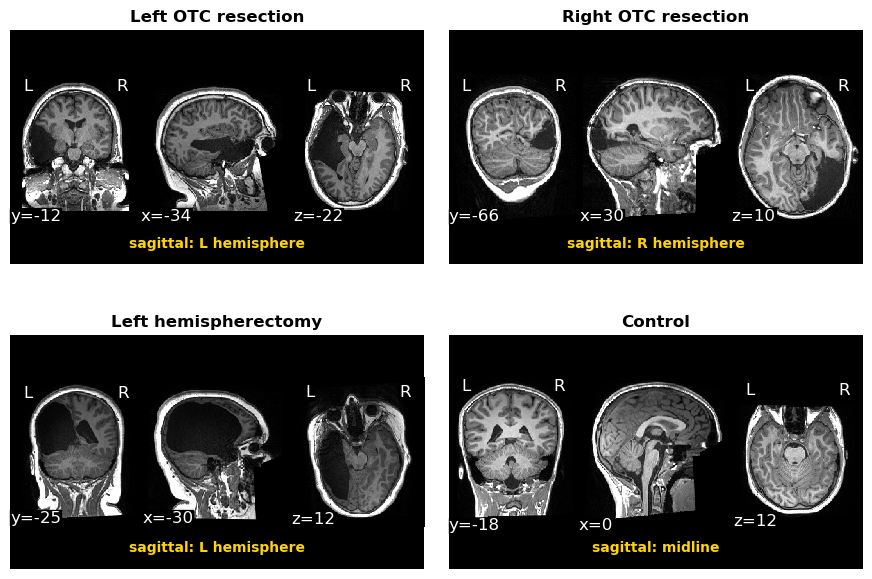

In [5]:
#!/usr/bin/env python
"""
Representative anatomy figure: one exemplar per surgery type + one control = 4 panels (2x2).
RUN ON THE CLUSTER. Cut coords are starting guesses — tune against each scan.
Heads equalized by tight head-bbox crop (world coords preserved). Sagittal (middle)
view labeled with its hemisphere (from cut x-sign).
"""
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib import gridspec
from nilearn import image, plotting

RAW_DIR = "/lab_data/behrmannlab/hemi/Raw"     # adjust if T1s live elsewhere
SES = "ses-01"
T1  = "{raw}/{sub}/{ses}/anat/{sub}_{ses}_T1w.nii.gz"
DIM = -1.25

# (row, col, sub, title two-line, (x,y,z) cut)
PANELS = [
    (0,0,"sub-044","Left OTC resection",   (-34,-12,-22)),
    (0,1,"sub-004","Right OTC resection",  ( 30,-66, 10)),
    (1,0,"sub-099","Left hemispherectomy", (-30,-25, 12)),
    (1,1,"sub-094","Control",              (  0,-18, 12)),
]

MARGIN = {"sub-044": 20}   # zero-background frame (voxels); larger = smaller head

def tight_crop(img, margin=6, frac=0.12):
    """Crop to head bbox, then add `margin` voxels of real zero-background on every
    side so the head occupies less of the FOV. World coords preserved."""
    d = img.get_fdata()
    thr = frac * np.percentile(d, 99.5)
    mask = d > thr
    if mask.sum() == 0: return img
    idx = np.array(np.where(mask))
    lo = idx.min(1); hi = idx.max(1) + 1
    sl = tuple(slice(int(a), int(b)) for a, b in zip(lo, hi))
    d = np.pad(d[sl], margin, mode="constant")
    aff = img.affine.copy()
    aff[:3, 3] = aff[:3, 3] + aff[:3, :3].dot(lo - margin)
    return nib.Nifti1Image(d, aff)

def show(ax, sub, title, cut):
    path = T1.format(raw=RAW_DIR, sub=sub, ses=SES)
    if not os.path.exists(path):
        ax.text(0.5,0.5,f"{title}\n(T1 not found)",ha="center",va="center",fontsize=9); ax.axis("off"); return
    anat = tight_crop(image.load_img(path), margin=MARGIN.get(sub, 6))
    plotting.plot_anat(anat, cut_coords=cut, draw_cross=False, dim=DIM, axes=ax, annotate=True)
    ax.set_title(title, fontsize=12, fontweight="bold")
    sag = "midline" if abs(cut[0]) < 5 else ("R hemisphere" if cut[0] > 0 else "L hemisphere")
    ax.text(0.5, 0.06, f"sagittal: {sag}", transform=ax.transAxes, ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#FFD400")

fig = plt.figure(figsize=(11, 7))
gs = gridspec.GridSpec(2, 2, hspace=0.30, wspace=0.06)
for r, c, sub, title, cut in PANELS:
    show(fig.add_subplot(gs[r, c]), sub, title, cut)